# HFO Evaluation on Real-Time sEEG Data using an snn-torch-trained Network

## Check WD (change if necessary) and file loading

In [51]:
# Show current directory
import os
curr_dir = os.getcwd()
print(curr_dir)

# Check if the current WD is the file location
if "/thesis-lava/src/nir" not in os.getcwd():
    # Set working directory to this file location
    file_location = f"{os.getcwd()}/thesis-lava/src/nir"
    print("File Location: ", file_location)

    # Change the current working Directory
    os.chdir(file_location)

    # New Working Directory
    print("New Working Directory: ", os.getcwd())

/home/monkin/Desktop/feup/thesis/thesis-lava/src/nir


### Add Parent Directory to Path
Need to add it to access `utils` without adding it to PATH

In [52]:
# Add grandparent directory to path (To acess sntt_utils)
import sys

current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
# Add the grandparent directory to the system path
# grandparent_dir = os.path.abspath(os.path.join(current_dir, os.pardir, os.pardir))
# sys.path.append(parent_dir)
sys.path.insert(0, parent_dir)


print(sys.path)

['/home/monkin/Desktop/feup/thesis/thesis-lava/src', '/home/monkin/Desktop/feup/thesis/thesis-lava/src', '/home/monkin/Desktop/feup/thesis', '/home/monkin/Desktop/feup/ncn-lava/src', '/home/monkin/Desktop/feup/thesis/thesis-lava/src', '/home/monkin/Desktop/feup/thesis/lava-dl/src', '/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/home/monkin/Desktop/feup/thesis/.venv/lib/python3.10/site-packages', '/home/monkin/Desktop/feup/thesis/lava-dl', '/home/monkin/Desktop/feup/thesis/.venv/src/lava/src', '/home/monkin/Desktop/feup/thesis/.venv/src/lava', '/home/monkin/Desktop/feup/thesis/.venv/lib/python3.10/site-packages/setuptools/_vendor']


## Load the Network from the `NIR` file

In [53]:
from utils.hfo import band_to_file_name, MarkerType, BaselineAlgorithm

# ----- Frequency Band Parameters -----
# Declare if using ripples, fast ripples, or both
chosen_band = MarkerType.FAST_RIPPLE     # RIPPLE, FAST_RIPPLE, or BOTH
# Specify the chosen Baseline Algorithm
chosen_baseline_alg_suffix = BaselineAlgorithm.MEDIAN # BaselineAlgorithm.EIGHTY_PERC    # BaselineAlgorithm.Q3
# Get the suffix for the chosen frequency band
BAND_FILENAME = band_to_file_name(chosen_band)

In [54]:
import numpy as np
import nir
import matplotlib.pyplot as plt

# Load the Trained Network from the NIR File
NIR_FILENAME = f"{BAND_FILENAME}_{chosen_baseline_alg_suffix}_trained_net.nir"

nir_network = nir.read(f"models/{NIR_FILENAME}")

### Analyze individual Layers of the imported Network

In [55]:
nirLIF1 = nir_network.nodes["lif1"]
nirLIF2 = nir_network.nodes["lif2"]
nirLIFOut = nir_network.nodes["lif_out"]
print(nirLIF1)

CubaLIF(tau_syn=array([0.00027337, 0.00020684, 0.00029694, 0.0001266 , 0.00028942,
       0.00017805, 0.00018086, 0.00020547, 0.00024664, 0.00011793,
       0.00029177, 0.00020036, 0.00029843, 0.00025447, 0.00028037,
       0.0001865 , 0.00017841, 0.0019396 , 0.00040969, 0.00037363,
       0.00015701, 0.00015839, 0.00016286, 0.00012814], dtype=float32), tau_mem=array([0.00011864, 0.00023361, 0.00015698, 0.00017259, 0.00034534,
       0.00014197, 0.00015067, 0.00051802, 0.00033085, 0.00021419,
       0.00019028, 0.00016002, 0.00017566, 0.00015763, 0.00017741,
       0.00020649, 0.00012887, 0.00017213, 0.00013625, 0.00027133,
       0.00017605, 0.00081964, 0.00023196, 0.00011435], dtype=float32), r=array([1.1863538, 2.3360846, 1.5698305, 1.7258911, 3.4533699, 1.4196671,
       1.5067121, 5.1802025, 3.3085303, 2.1418586, 1.9027638, 1.6001774,
       1.7566377, 1.5762817, 1.7740619, 2.0649114, 1.2887096, 1.7213036,
       1.3625021, 2.7133477, 1.7605472, 8.196443 , 2.3196158, 1.1435146],
 

In [56]:
# Calculate the dv and du parameters from tau_mem and tau_syn
lif1_dv = np.array(list(map(lambda x: (1e-4 / x), nirLIF1.tau_mem)))
lif1_du = np.array(list(map(lambda x: (1e-4 / x), nirLIF1.tau_syn)))

lif2_dv = np.array(list(map(lambda x: (1e-4 / x), nirLIF2.tau_mem)))
lif2_du = np.array(list(map(lambda x: (1e-4 / x), nirLIF2.tau_syn)))

lif_out_dv = (1e-4 / nirLIFOut.tau_mem)
lif_out_du = (1e-4 / nirLIFOut.tau_syn)

In [57]:
nirLIFOut

CubaLIF(tau_syn=np.float32(0.00025984697), tau_mem=np.float32(0.00025984686), r=np.float32(2.5984685), v_leak=np.float32(0.0), v_threshold=np.float32(1.0), w_in=np.float32(2.5984697), input_type={'input': array([], dtype=float64)}, output_type={'output': array([], dtype=float64)}, metadata={}, num_neurons=np.int64(1))

In [58]:
# Print the network summary
print(f"NIR Network Info: Nº Nodes: {len(nir_network.nodes)} | Nº Edges: {len(nir_network.edges)}")

print("Nodes: ", nir_network.nodes)
print(f"\nLIF Nodes dv and du: LIF1: dv: {lif1_dv} | du: {lif1_du}\nLIF2: dv: {lif2_dv} | du: {lif2_du}\nLIFOut: dv: {lif_out_dv} | du: {lif_out_du}")

print("\nEdges: ", nir_network.edges)

NIR Network Info: Nº Nodes: 8 | Nº Edges: 7
Nodes:  {'fc3': Linear(weight=array([[-1.11489333e-01, -2.68412918e-01, -3.24451417e-01,
         6.16860867e-01, -3.27180773e-01, -2.12263197e-01,
        -1.17689617e-01, -2.33668327e-01,  5.08770943e-01,
        -4.38423663e-01,  4.84119266e-01,  5.60897887e-01,
        -3.88121665e-01,  6.27892852e-01,  2.49766069e-03,
         4.52961385e-01, -9.30073857e-02,  6.34308040e-01,
         6.06913209e-01, -4.26406972e-02,  9.06697035e-01,
         5.93553901e-01, -3.50169949e-02, -8.73716474e-02],
       [ 4.99247432e-01, -1.59530684e-01, -4.45856247e-03,
         7.08272755e-01,  4.83858675e-01,  4.60404038e-01,
         8.41623485e-01,  4.03165221e-01, -4.95698377e-02,
        -1.76092297e-01, -1.59834176e-01,  5.57745457e-01,
         4.06628132e-01,  5.90626299e-01,  4.01989132e-01,
         4.52161670e-01,  5.40686071e-01,  4.61366415e-01,
         5.68166554e-01, -1.86424062e-01, -4.92532272e-03,
         5.76662421e-01, -6.11825660e-02

In [59]:
from typing import TypedDict

class LifNode(TypedDict):
    tau_syn: np.float32
    tau_mem: np.float32
    r: np.float32
    v_leak: np.float32
    v_threshold: np.float32
    w_in: np.float32
    input_type: dict[str, list[np.float64]]
    output_type: dict[str, list[np.float64]]
    metadata: dict
    num_neurons: np.int64

nirLifOut: LifNode = nir_network.nodes["lif_out"]

## Transform the NIR Representation to a Lava Network

In [60]:
from nir_to_lava_edit import ImportConfig, LavaLibrary, import_from_nir
# from nir_to_lava import ImportConfig, LavaLibrary, import_from_nir

nir_dt = 1e-4
config = ImportConfig(
    dt=nir_dt, fixed_pt=False, on_chip=False, library_preference=LavaLibrary.Lava,
)

In [61]:
lava_net, startNodes, endNodes = import_from_nir(
    nir_network,  # ng, # 
    config
)

In [62]:
print(lava_net)
print(startNodes)
print(endNodes)

{'fc3': <lava.proc.dense.process.Dense object at 0x7f8461039240>, 'fc_in': <lava.proc.dense.process.Dense object at 0x7f8462227250>, 'fc_out': <lava.proc.dense.process.Dense object at 0x7f846001ceb0>, 'lif1': <lava.proc.lif.process.LIF object at 0x7f846001e230>, 'lif2': <lava.proc.lif.process.LIF object at 0x7f846001e0e0>, 'lif_out': <lava.proc.lif.process.LIF object at 0x7f846001f7f0>}
['fc_in']
['lif_out']


In [63]:
print(f"fc_in weights: {lava_net['fc_in'].weights}")

# print(f"\n\nLIF1 Dense Layer weights: {lava_net['lif1'][0].weights}")

print(f"\n\nfc3 Dense Layer weights: {lava_net['fc3'].weights}")

# print(f"\n\nLIF2 Dense Layer weights: {lava_net['lif2'][0].weights}")

print(f"\n\nfc_out Dense Layer weights: {lava_net['fc_out'].weights}")

# print(f"\n\nLIF2 Dense Layer weights: {lava_net['lif_out'][0].weights}")

fc_in weights: Variable: weights
    shape: (24, 2)
    init: [[-0.06875768  0.3632544 ]
 [-0.06991412  0.3014826 ]
 [-0.08799023 -0.40139914]
 [-0.01142708  0.3069516 ]
 [-0.14343071  0.28744662]
 [-0.6771706   0.26339507]
 [ 0.08243496 -0.32075056]
 [-0.16788197  0.32528844]
 [-0.49979237  0.31321138]
 [ 0.10769798  0.14453843]
 [ 0.5032711   0.02158791]
 [ 0.6983852  -0.44930574]
 [ 0.2799653  -0.68635434]
 [-0.20351513 -0.46896067]
 [ 0.28301492  0.25344634]
 [ 0.05520425 -0.21891521]
 [-0.04046844  0.40300378]
 [-0.367016   -0.0208347 ]
 [-0.02016602  0.15802248]
 [-0.35941204  0.4433338 ]
 [-0.04973699  0.21267779]
 [-0.17650871  0.11278259]
 [-0.40157005 -0.39972392]
 [ 0.24134645  0.27367538]]
    shareable: True
    value: [[-0.06875768  0.3632544 ]
 [-0.06991412  0.3014826 ]
 [-0.08799023 -0.40139914]
 [-0.01142708  0.3069516 ]
 [-0.14343071  0.28744662]
 [-0.6771706   0.26339507]
 [ 0.08243496 -0.32075056]
 [-0.16788197  0.32528844]
 [-0.49979237  0.31321138]
 [ 0.10769798  

Every `LIF` Layer contains a `Dense` Layer with Diagonal Weights. I'm not sure why these weights are needed...

### Print the ports of the Network Processes

In [64]:
# Print the Network Ports
for key, proc in lava_net.items():
    print(f"Key: {key} | Proc: {proc}")

    if isinstance(proc, list):
        # Network Node contains multiple Processes
        # Note: Max Depth is 2
        for inner_key, inner_proc in enumerate(proc):
            print(f"Key: ({key},{inner_key}) | Proc: {inner_proc}")
            # Print the Network Ports
            for port in inner_proc.in_ports:
                print(f"Proc: {inner_proc.name:<5} Port Name: {port.name:<5} Size: {port.size}")
            for port in inner_proc.out_ports:
                print(f"Proc: {inner_proc.name:<5} Port Name: {port.name:<5} Size: {port.size}")
    else:
        # Print the Network Ports
        for port in proc.in_ports:
            print(f"Proc: {proc.name:<5} Port Name: {port.name:<5} Size: {port.size}")
        for port in proc.out_ports:
            print(f"Proc: {proc.name:<5} Port Name: {port.name:<5} Size: {port.size}")

Key: fc3 | Proc: <lava.proc.dense.process.Dense object at 0x7f8461039240>
Proc: Process_14 Port Name: s_in  Size: 24
Proc: Process_14 Port Name: a_out Size: 16
Key: fc_in | Proc: <lava.proc.dense.process.Dense object at 0x7f8462227250>
Proc: Process_15 Port Name: s_in  Size: 2
Proc: Process_15 Port Name: a_out Size: 24
Key: fc_out | Proc: <lava.proc.dense.process.Dense object at 0x7f846001ceb0>
Proc: Process_16 Port Name: s_in  Size: 16
Proc: Process_16 Port Name: a_out Size: 1
Key: lif1 | Proc: <lava.proc.lif.process.LIF object at 0x7f846001e230>
Proc: cuba lif Port Name: a_in  Size: 24
Proc: cuba lif Port Name: s_out Size: 24
Key: lif2 | Proc: <lava.proc.lif.process.LIF object at 0x7f846001e0e0>
Proc: cuba lif Port Name: a_in  Size: 16
Proc: cuba lif Port Name: s_out Size: 16
Key: lif_out | Proc: <lava.proc.lif.process.LIF object at 0x7f846001f7f0>
Proc: cuba lif Port Name: a_in  Size: 1
Proc: cuba lif Port Name: s_out Size: 1


### Get the Lava's Equivalent Start Process and Input / Output Ports

In [65]:
# Define the Start Process of the Imported Network
startProc = lava_net[startNodes[0]]

# Test: Print the Ports of the Start Process
in_port = startProc.a_in if hasattr(startProc, "a_in") else startProc.s_in
out_port = startProc.a_out if hasattr(startProc, "a_out") else startProc.s_out

print("In Port: ", in_port, " | Size: ", in_port.size)
print("Out Port: ", out_port, " | Size: ", out_port.size)

In Port:  <lava.magma.core.process.ports.ports.InPort object at 0x7f8462227280>  | Size:  2
Out Port:  <lava.magma.core.process.ports.ports.OutPort object at 0x7f846001c790>  | Size:  24


## Add a Refractory Period to the `LIF_OUT` Neurons

In [66]:
from utils.hfo import band_to_gt_max_offset

PRED_CAUSALITY_WINDOW = int(5)     # Giving PRED_CAUSALITY_WINDOW ms for the network to update its inner state and spike   

# in timesteps (ms) - Max time from the Insertion Timing to the GT annotation
MAX_DETECTION_OFFSET = int(band_to_gt_max_offset(chosen_band)) * 1.5 + PRED_CAUSALITY_WINDOW   # in timesteps (ms)

print(f"PRED_CAUSALITY_WINDOW: {PRED_CAUSALITY_WINDOW}")
print(f"MAX_DETECTION_OFFSET: {MAX_DETECTION_OFFSET} ms")

PRED_CAUSALITY_WINDOW: 5
MAX_DETECTION_OFFSET: 32.0 ms


In [67]:
from lava.proc.lif.process import LIFRefractory
from math import floor

# Add refractory period to lif_out neurons
# lif_out = lava_net["lif_out"][1]  # NOTE: Used when the nir_node_to_lava function returns a list of processes for LIF nodes
lif_out = lava_net["lif_out"]
# print("LIF Out: ", lif_out)


REFRAC_PERIOD = 200     # floor(MAX_DETECTION_OFFSET) * 2    # Number of time-steps for the refractory period
print(f"Refractory Period: {REFRAC_PERIOD} steps")

Refractory Period: 200 steps


In [68]:
# Calculate the dv and du from the time constants
dv_lif_out = (nir_dt / nirLifOut.tau_mem)
du_lif_out = (nir_dt / nirLifOut.tau_syn)
print(f"dv_lif_out: {dv_lif_out} | du_lif_out: {du_lif_out}")

dv_lif_out: 0.38484203815460205 | du_lif_out: 0.3848418891429901


In [69]:
# TODO: Need to check which parameters I need to copy from the NIR representation and if they need to be converted
lif_out_refrac = LIFRefractory(
    shape=(1,),  # There is 1 output neuron
    vth=nirLifOut.v_threshold,
    dv=dv_lif_out,    # Inverse of decay time-constant for voltage decay
    du=du_lif_out,  # Inverse of decay time-constant for current decay
    refractory_period=REFRAC_PERIOD,
    name="cuba lif"
)

### Change the Port Connections to the Refractory Neurons

In [70]:
USE_REFRAC_NEURON = True
if USE_REFRAC_NEURON:
    # Replace the original lif_out with the new one
    # lava_net["lif_out"][1] = lif_out_refrac
    lava_net["lif_out"] = lif_out_refrac


    # Make the port connections
    # lava_net["lif_out"][0].a_out.connect(lif_out_refrac.a_in)
    lava_net["fc_out"].a_out.connect(lif_out_refrac.a_in)

    lif_out = lif_out_refrac

In [71]:
lava_net

{'fc3': <lava.proc.dense.process.Dense at 0x7f8461039240>,
 'fc_in': <lava.proc.dense.process.Dense at 0x7f8462227250>,
 'fc_out': <lava.proc.dense.process.Dense at 0x7f846001ceb0>,
 'lif1': <lava.proc.lif.process.LIF at 0x7f846001e230>,
 'lif2': <lava.proc.lif.process.LIF at 0x7f846001e0e0>,
 'lif_out': <lava.proc.lif.process.LIFRefractory at 0x7f8460f98850>}

## Read the Input Data and the Ground Truth

In [72]:
IS_CLINICAL = False
PATIENT_LABEL = "csl"
INPUT_TYPE = "clinical" if IS_CLINICAL else "synthetic"

In [73]:
from utils.io import preview_np_array

# Define the channel suffix (Channel range indicates a certain Brain Region & SNR level)
CH_SUFFIX = "ch90-119"  # "ch90-119"

# Get the suffix for the chosen frequency band
BAND_FILENAME = band_to_file_name(chosen_band)

# Define the INPUT Folder
INPUT_FOLDER = f"input_data/{BAND_FILENAME}_{chosen_baseline_alg_suffix}_{CH_SUFFIX}"

In [74]:
# Load the input data
up_spikes = np.load(f"{INPUT_FOLDER}/up_spike_train.npy")
down_spikes = np.load(f"{INPUT_FOLDER}/down_spike_train.npy")
# Load the Ground Truth
gt_data = np.load(f"{INPUT_FOLDER}/gt_data.npy")

# Print the shape of the loaded data
print("Up Spikes Shape: ", up_spikes.shape)
print("Down Spikes Shape: ", down_spikes.shape)
print("GT Data Shape: ", gt_data.shape)

Up Spikes Shape:  (175135,)
Down Spikes Shape:  (175019,)
GT Data Shape:  (720,)


In [75]:
# See the time of the first and last UP / DN spikes
first_up, last_up = up_spikes[0], up_spikes[-1]
first_dn, last_dn = down_spikes[0], down_spikes[-1]

print(f"First Up Spike: {first_up} | Last Up Spike: {last_up}")
print(f"First Down Spike: {first_dn} | Last Down Spike: {last_dn}")

First Up Spike: 206.54296875 | Last Up Spike: 3599996.58203125
First Down Spike: 205.56640625 | Last Down Spike: 3599997.55859375


## Create Input Node to feed the UP / Down Spike Trains

In [76]:
from utils.input import INPUT_DURATION, NUM_CH_PER_SNR 

# Simulation Time Parameters
num_steps = int(INPUT_DURATION)     # int(INPUT_DURATION * NUM_CH_PER_SNR)    # Number of steps to run the simulation   # TODO: CAREFUL WITH THIS DURATION (INPUT_DURATION IS THE DURATION OF THE SYNTHETIC DATA)
num_channels = NUM_CH_PER_SNR
init_offset = 0 # 900 # 33400      #   
virtual_time_step_interval = 1  # dt = 1 ms

print(f"Num Steps: {num_steps}")

Num Steps: 120000


In [77]:
spike_evts = np.array([up_spikes, down_spikes], dtype=object)  # Use dtype=object to allow variable-length arrays
print(f"Spike Events shape: {spike_evts.shape} | Value= {spike_evts}")

Spike Events shape: (2,) | Value= [array([2.06542969e+02, 2.09472656e+02, 2.11914062e+02, ...,
        3.59998438e+06, 3.59998730e+06, 3.59999658e+06], shape=(175135,))
 array([2.05566406e+02, 2.08007812e+02, 2.10937500e+02, ...,
        3.59998584e+06, 3.59999512e+06, 3.59999756e+06], shape=(175019,))]


In [85]:
'''
Split the UP and DOWN Spikes by the number of channels.
Each Channel has NUM_STEPS_PER_CH timesteps
'''
up_spikes_per_ch, down_spikes_per_ch = np.ndarray(shape=(NUM_CH_PER_SNR,), dtype=object), np.ndarray(shape=(NUM_CH_PER_SNR,), dtype=object)

for up_spike in up_spikes:
    ch_idx = int(up_spike // INPUT_DURATION)
    if up_spikes_per_ch[ch_idx] is None:
        # Remove the first None element
        up_spikes_per_ch[ch_idx] = np.array([up_spike - (ch_idx * INPUT_DURATION)], dtype=np.float64)
    else:
        up_spikes_per_ch[ch_idx] = np.append(up_spikes_per_ch[ch_idx], up_spike - (ch_idx * INPUT_DURATION))
for down_spike in down_spikes:
    ch_idx = int(down_spike // INPUT_DURATION)
    if down_spikes_per_ch[ch_idx] is None:
        # Remove the first None element
        down_spikes_per_ch[ch_idx] = np.array([down_spike - (ch_idx * INPUT_DURATION)], dtype=np.float64)
    else:
        down_spikes_per_ch[ch_idx] = np.append(down_spikes_per_ch[ch_idx], down_spike - (ch_idx * INPUT_DURATION))

# Print the shape of the loaded data
print("Up Spikes Per Channel Shape: ", up_spikes_per_ch.shape)
print("Down Spikes Per Channel Shape: ", down_spikes_per_ch.shape)

Up Spikes Per Channel Shape:  (30,)
Down Spikes Per Channel Shape:  (30,)


In [91]:
# Check if UP spikes are more or less distributed by the INPUT CHANNELS
for ch_idx in range(NUM_CH_PER_SNR):
    ch_up_spikes = up_spikes_per_ch[ch_idx].size
    ch_down_spikes = down_spikes_per_ch[ch_idx].size
    print(f"Nº UP / DN Spikes for Channel {ch_idx}: {ch_up_spikes}({round((ch_up_spikes / up_spikes.size)*100, 2)}%) / {ch_down_spikes}({round((ch_down_spikes / down_spikes.size)*100, 2)}%)")

Nº UP / DN Spikes for Channel 0: 5513(3.15%) / 5525(3.16%)
Nº UP / DN Spikes for Channel 1: 6147(3.51%) / 6144(3.51%)
Nº UP / DN Spikes for Channel 2: 6049(3.45%) / 6036(3.45%)
Nº UP / DN Spikes for Channel 3: 5921(3.38%) / 5912(3.38%)
Nº UP / DN Spikes for Channel 4: 5632(3.22%) / 5632(3.22%)
Nº UP / DN Spikes for Channel 5: 5901(3.37%) / 5882(3.36%)
Nº UP / DN Spikes for Channel 6: 5654(3.23%) / 5640(3.22%)
Nº UP / DN Spikes for Channel 7: 6042(3.45%) / 6040(3.45%)
Nº UP / DN Spikes for Channel 8: 5679(3.24%) / 5669(3.24%)
Nº UP / DN Spikes for Channel 9: 5703(3.26%) / 5698(3.26%)
Nº UP / DN Spikes for Channel 10: 5849(3.34%) / 5843(3.34%)
Nº UP / DN Spikes for Channel 11: 6183(3.53%) / 6179(3.53%)
Nº UP / DN Spikes for Channel 12: 6015(3.43%) / 6004(3.43%)
Nº UP / DN Spikes for Channel 13: 5508(3.15%) / 5516(3.15%)
Nº UP / DN Spikes for Channel 14: 6014(3.43%) / 6012(3.44%)
Nº UP / DN Spikes for Channel 15: 5958(3.4%) / 5953(3.4%)
Nº UP / DN Spikes for Channel 16: 5939(3.39%) / 5931

As we can see, the spikes were well distributed.

### Create the Input Generator Layer and Connect it to the remaining Network

In [28]:
from utils.spike_event_gen import SpikeEventGen_v2

# Create the Input Process
spike_event_gen = SpikeEventGen_v2(out_shape=(2,), spike_events=spike_evts, name="InputLayer",
                            virtual_time_step_interval=virtual_time_step_interval, init_offset=init_offset)

In [29]:
# Connect the Input Layer to the First Layer of the Trained HFO Detector
# If I connect the SpikeEventGen to the Dense Layer, the a_out value of the custom input will be rounded to 0 or 1 in the Dense Layer (it will not be a float) 
spike_event_gen.s_out.connect(in_port)

# Run the Network

## Record Internal Variables

In [30]:
# Get the Lava's LIF Objects corresponding to each of the LIF Nodes
lif1 = lava_net["lif1"] # [1]
lif2 = lava_net["lif2"] # [1]
lif_out = lava_net["lif_out"]   # [1]

print("LIF1: ", lif1)
print("LIF2: ", lif2)
print("LIF_OUT: ", lif_out)

LIF1:  <lava.proc.lif.process.LIF object at 0x7f83472e8df0>
LIF2:  <lava.proc.lif.process.LIF object at 0x7f83472e97b0>
LIF_OUT:  <lava.proc.lif.process.LIFRefractory object at 0x7f83472eb130>


In [31]:
from lava.proc.monitor.process import Monitor

monitor_lif1_v = Monitor()
monitor_lif1_u = Monitor()

monitor_lif2_v = Monitor()
monitor_lif2_u = Monitor()

monitor_lif_out_v = Monitor()
monitor_lif_out_u = Monitor()

# NOTE: IF we want to reduce the number of steps for debugging
# num_steps = 50000    # 15000     # TODO: Check the number of steps to run the simulation for

# Connect the monitors to the variables we want to monitor
MONITOR_ALL = False
if MONITOR_ALL:
    monitor_lif1_v.probe(lif1.v, num_steps)
    monitor_lif1_u.probe(lif1.u, num_steps)

    monitor_lif2_v.probe(lif2.v, num_steps)
    monitor_lif2_u.probe(lif2.u, num_steps)

monitor_lif_out_v.probe(lif_out.v, num_steps)
monitor_lif_out_u.probe(lif_out.u, num_steps)

In [32]:
from lava.magma.core.run_conditions import RunContinuous, RunSteps
from lava.magma.core.run_configs import Loihi1SimCfg

# run_condition = RunContinuous()   # TODO: Change to this one
run_condition = RunSteps(num_steps=num_steps)
run_cfg = Loihi1SimCfg(select_tag="floating_pt")   # TODO: Check why we need this select_tag="floating_pt"

In [33]:
spike_event_gen.run(condition=run_condition, run_cfg=run_cfg)

/home/monkin/Desktop/feup/thesis/thesis-lava/src/lava/magma/compiler/compiler_graphs.py:895: UserWarning: Cannot import module '<module 'snn' from '/home/monkin/Desktop/feup/thesis/thesis-lava/src/utils/snn.py'>' when searching ProcessModels for Process 'SpikeEventGen_v2'.
  warnings.warn(


Time step: 1000
Time step: 2000
Time step: 3000
Time step: 4000
Time step: 5000
Time step: 6000
Time step: 7000
Time step: 8000
Time step: 9000
Time step: 10000
Time step: 11000
Time step: 12000
Time step: 13000
Time step: 14000
Time step: 15000
Time step: 16000
Time step: 17000
Time step: 18000
Time step: 19000
Time step: 20000
Time step: 21000
Time step: 22000
Time step: 23000
Time step: 24000
Time step: 25000
Time step: 26000
Time step: 27000
Time step: 28000
Time step: 29000
Time step: 30000
Time step: 31000
Time step: 32000
Time step: 33000
Time step: 34000
Time step: 35000
Time step: 36000
Time step: 37000
Time step: 38000
Time step: 39000
Time step: 40000
Time step: 41000
Time step: 42000
Time step: 43000
Time step: 44000
Time step: 45000
Time step: 46000
Time step: 47000
Time step: 48000
Time step: 49000
Time step: 50000
Time step: 51000
Time step: 52000
Time step: 53000
Time step: 54000
Time step: 55000
Time step: 56000
Time step: 57000
Time step: 58000
Time step: 59000
Time s

Process SystemProcess-8:
Process SystemProcess-11:
Process SystemProcess-9:
Process SystemProcess-10:
Process SystemProcess-4:
Process SystemProcess-2:
Process SystemProcess-5:
Process SystemProcess-7:
Process SystemProcess-3:
Process SystemProcess-12:
Process SystemProcess-6:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiprocessing/proce

KeyboardInterrupt: 

## Retrieve Recorded Data

In [34]:
if MONITOR_ALL:
    data_lif1_v = monitor_lif1_v.get_data()
    data_lif1_u = monitor_lif1_u.get_data()

    data_lif2_v = monitor_lif2_v.get_data()
    data_lif2_u = monitor_lif2_u.get_data()

    data_lif1 = data_lif1_v.copy()
    data_lif1["cuba lif"]["u"] = data_lif1_u["cuba lif"]["u"]   # Merge the dictionaries to contain both voltage and current

    data_lif2 = data_lif2_v.copy()
    data_lif2["cuba lif"]["u"] = data_lif2_u["cuba lif"]["u"]   # Merge the dictionaries to contain both voltage and current

data_lif_out_v = monitor_lif_out_v.get_data()
data_lif_out_u = monitor_lif_out_u.get_data()

data_lif_out = data_lif_out_v.copy()
data_lif_out["cuba lif"]["u"] = data_lif_out_u["cuba lif"]["u"]   # Merge the dictionaries to contain both voltage and current

In [35]:
if MONITOR_ALL:
    print(f"Shape of LIF 1 Voltage Data: {data_lif1_v['cuba lif']['v'].shape}")
    data_lif1

In [36]:
if MONITOR_ALL:
    print(f"Shape of LIF 2 Voltage Data: {data_lif2_v['cuba lif']['v'].shape}")
    data_lif2

In [38]:
print(f"Shape of LIF OUT Voltage Data: {data_lif_out_v['cuba lif']['v'].shape}")
data_lif_out_v

AttributeError: 'NoneType' object has no attribute 'shape'

## Plot the Recorded Data

ValueError: x, y, and format string must not be None

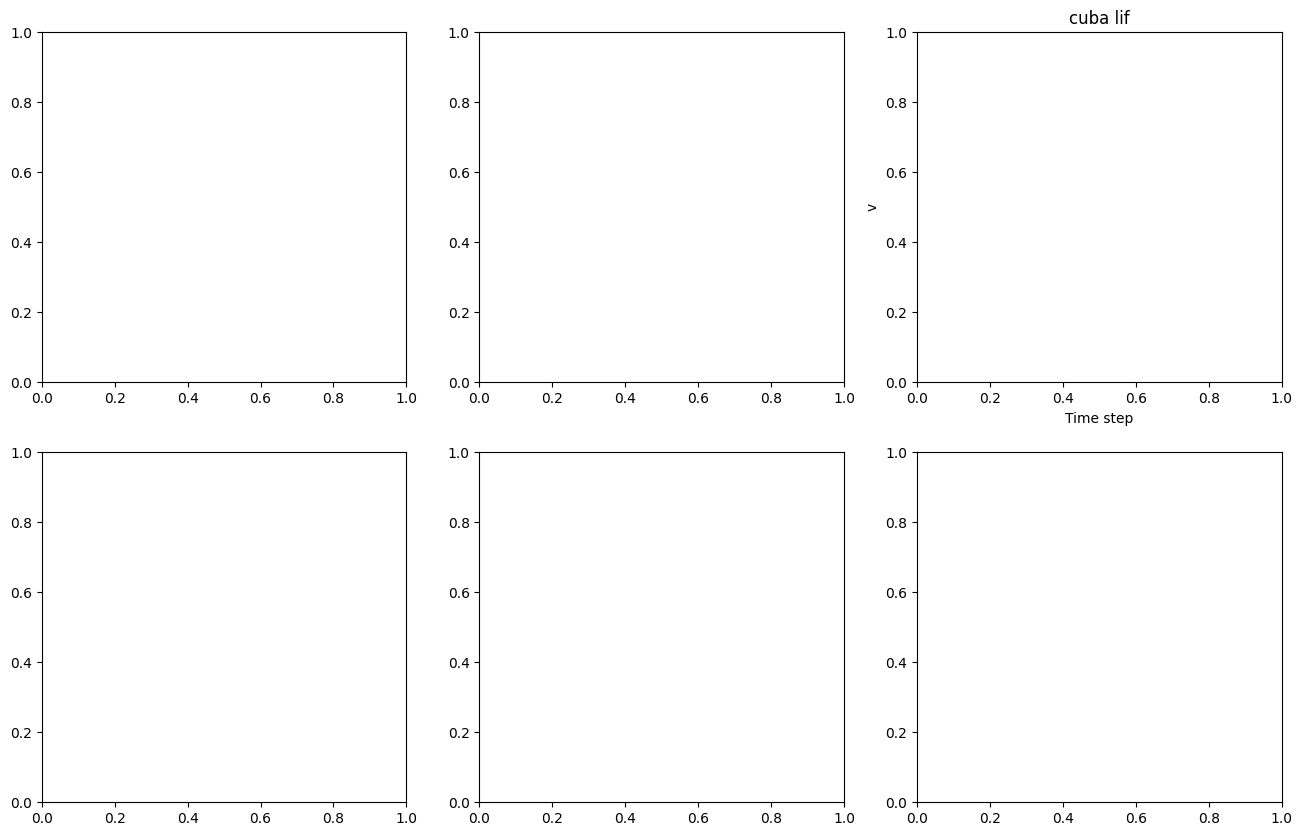

In [39]:
import matplotlib
%matplotlib inline
from matplotlib import pyplot as plt

# Create a subplot for each monitored variable
fig = plt.figure(figsize=(16, 10))
ax0 = fig.add_subplot(2, 3, 1)
ax1 = fig.add_subplot(2, 3, 2)
ax2 = fig.add_subplot(2, 3, 3)
ax3 = fig.add_subplot(2, 3, 4)
ax4 = fig.add_subplot(2, 3, 5)
ax5 = fig.add_subplot(2, 3, 6)

# Plot the data
if MONITOR_ALL:
    monitor_lif1_v.plot(ax0, lif1.v)
    monitor_lif2_v.plot(ax1, lif2.v)
monitor_lif_out_v.plot(ax2, lif_out.v)

if MONITOR_ALL:
    monitor_lif1_u.plot(ax3, lif1.u)
    monitor_lif2_u.plot(ax4, lif2.u)
monitor_lif_out_u.plot(ax5, lif_out.u)

# Set the Title of each Subplot
ax0.set_xlabel('Time Step')
ax0.set_ylabel('Voltage (V)')
ax0.set_title('LIF 1 Voltage / Step')
ax1.set_ylabel('Voltage (V)')
ax1.set_title('LIF 2 Voltage / Step')
ax2.set_ylabel('Voltage (V)')
ax2.set_title('LIF OUT Voltage / Step')


ax3.set_ylabel('Current (U)')
ax3.set_title('LIF 1 Current / Step')
ax4.set_ylabel('Current (U)')
ax4.set_title('LIF 2 Current / Step')
ax5.set_ylabel('Current (U)')
ax5.set_title('LIF OUT Current / Step')

## Find the timesteps where the network spiked

In [ ]:
from utils.data_analysis import find_spike_times

lif_out_voltage = np.array(data_lif_out['cuba lif']['v'])
lif_out_current_vals = np.array(data_lif_out['cuba lif']['u'])
# preview_np_array(voltage_arr_1, "Voltage Array")

# Call the find_spike_times util function that detects the spikes in a voltage array
# TODO: Improve the find_spike_times method to view the current of the preview timestep to make sure it is a spike, instead of an inhibition
spike_times_lif_out = find_spike_times(lif_out_voltage, lif_out_current_vals)

print(f"Found {len(spike_times_lif_out)} spikes in the Output LIF Process")
for (spike_time, neuron_idx) in spike_times_lif_out:
    print(f"Spike time: {init_offset + spike_time * virtual_time_step_interval} (iter. {spike_time}) at neuron: {neuron_idx}")

Found 20 spikes in the Output LIF Process
Spike time: 4221 (iter. 4221) at neuron: 0
Spike time: 6975 (iter. 6975) at neuron: 0
Spike time: 9796 (iter. 9796) at neuron: 0
Spike time: 13201 (iter. 13201) at neuron: 0
Spike time: 18184 (iter. 18184) at neuron: 0
Spike time: 24482 (iter. 24482) at neuron: 0
Spike time: 33307 (iter. 33307) at neuron: 0
Spike time: 36395 (iter. 36395) at neuron: 0
Spike time: 39140 (iter. 39140) at neuron: 0
Spike time: 42465 (iter. 42465) at neuron: 0
Spike time: 53355 (iter. 53355) at neuron: 0
Spike time: 68472 (iter. 68472) at neuron: 0
Spike time: 71957 (iter. 71957) at neuron: 0
Spike time: 79889 (iter. 79889) at neuron: 0
Spike time: 83390 (iter. 83390) at neuron: 0
Spike time: 89455 (iter. 89455) at neuron: 0
Spike time: 98657 (iter. 98657) at neuron: 0
Spike time: 106040 (iter. 106040) at neuron: 0
Spike time: 107864 (iter. 107864) at neuron: 0
Spike time: 112017 (iter. 112017) at neuron: 0


## Compare the Network Predictions with the Ground Truth

In [ ]:
# Define np.array containing the timestep of GT events
gt_times = np.array([int(round(gt_elem[1])) for gt_elem in gt_data])

# Preview the data
preview_np_array(gt_times, "gt_times", edge_items=2)

gt_times Shape: (720,).
Preview: [   4219    6967 ... 3595019 3599000]


In [ ]:
real_spike_times = []

prev_spike_anchor = -1
for spike_time, _neuron_idx in spike_times_lif_out:
    if prev_spike_anchor < 0:
        real_spike_times.append(spike_time)
        prev_spike_anchor = spike_time
    else:
        # Check if the current spike time is within the range of the previous spike time
        if (spike_time - prev_spike_anchor) < REFRAC_PERIOD:
            # Skip this spike time
            continue
        else:
            real_spike_times.append(spike_time)
            prev_spike_anchor = spike_time

print(f"Found {len(real_spike_times)} real spikes in the Output LIF Process")
real_spike_times = np.array(real_spike_times)

# Change the number of values printed by numpy print
np.set_printoptions(threshold=1000)  # Set the threshold to a large value
print(real_spike_times)

Found 20 real spikes in the Output LIF Process
[  4221   6975   9796  13201  18184  24482  33307  36395  39140  42465
  53355  68472  71957  79889  83390  89455  98657 106040 107864 112017]


We will consider a prediction correct if the network spikes in the interval `[gt_time, gt_time + MAX_DETECTION_OFFSET]`.

In [ ]:
TP, TN, FP, FN = 0, 0, 0, 0

curr_gt_idx = 0

for spike_time in real_spike_times:
    # Check if the spike time is within the range of the GT times
    while curr_gt_idx < len(gt_times):
        gt_time = gt_times[curr_gt_idx]
        print(f"GT Time: {gt_time} | Spike Time: {spike_time}")
        if spike_time < gt_time:
            # This spike is before the insertion of a relevant event
            FP += 1
            break   # Exit the loop
        if (spike_time - gt_time) < MAX_DETECTION_OFFSET:
            # spike time must be >= gt_time
            TP += 1
            curr_gt_idx += 1
            break   # Exit the loop
        else:
            # The current spike is not relative to the next GT event
            # meaning that we did not predict the event
            FN += 1
            curr_gt_idx += 1
            continue   # Continue to the next GT event
    else:
        # No more GT events, so every spike is a false positive
        FP += 1


GT Time: 4219 | Spike Time: 4221
GT Time: 6967 | Spike Time: 6975
GT Time: 9794 | Spike Time: 9796
GT Time: 13189 | Spike Time: 13201
GT Time: 18186 | Spike Time: 18184
GT Time: 18186 | Spike Time: 24482
GT Time: 24476 | Spike Time: 24482
GT Time: 27047 | Spike Time: 33307
GT Time: 33302 | Spike Time: 33307
GT Time: 36388 | Spike Time: 36395
GT Time: 39140 | Spike Time: 39140
GT Time: 42460 | Spike Time: 42465
GT Time: 53347 | Spike Time: 53355
GT Time: 59794 | Spike Time: 68472
GT Time: 65384 | Spike Time: 68472
GT Time: 68471 | Spike Time: 68472
GT Time: 71948 | Spike Time: 71957
GT Time: 74835 | Spike Time: 79889
GT Time: 79887 | Spike Time: 79889
GT Time: 83374 | Spike Time: 83390
GT Time: 85944 | Spike Time: 89455
GT Time: 89456 | Spike Time: 89455
GT Time: 89456 | Spike Time: 98657
GT Time: 98651 | Spike Time: 98657
GT Time: 106037 | Spike Time: 106040
GT Time: 107859 | Spike Time: 107864
GT Time: 123918 | Spike Time: 112017


In [ ]:
# Show the Confusion Matrix
print(f"Confusion Matrix:")

# Print lines with same width
print(f"|TP: {TP} | FP: {FP}|\n|FN: {FN}  | TN: {TN}|")

Confusion Matrix:
|TP: 17 | FP: 3|
|FN: 7  | TN: 0|


In [ ]:
# Calculate the performance metrics (Not including metrics that rely on TN)
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

In [ ]:
# Output the performance metrics
print(f"Recall (True Positive Rate): {recall*100:.2f} %")
print(f"Precision (TP / (TP + FP)): {precision*100:.2f} %")
print(f"F1 Score (Combines Precision & Recall): {f1_score*100:.2f} %")

Recall (True Positive Rate): 70.83 %
Precision (TP / (TP + FP)): 85.00 %
F1 Score (Combines Precision & Recall): 77.27 %


As we can see, the network is detecting HFOs with good Recall, Precision and F1-Score. Thus, we can conclude that the network was successfully imported from `NIR` and is working in `LAVA`!

In [ ]:
total_predictions = TP + FP + FN
print(f"Total Predictions: {total_predictions}")

Total Predictions: 27


## Clean up the Network

In [ ]:
# Terminates Process Execution for all Network Nodes
spike_event_gen.stop()

# Export the results of the Classification to a JSON file
Export the results of the classification to a JSON file. This file will include:
- Frequency Band used (`Ripple`, `Fast Ripple` or `Both`).
- Channels Used.
- `num_steps`
- `Confidence Window` used
- Classification Metrics (`True Positives`, `False Positives`, `False Negatives`, `Precision`, `Recall`, `F1 Score`)

In [ ]:
import json

# Export the results to a JSON file
OUTPUT_FOLDER = f"eval/{INPUT_TYPE}"
# create the output folder if it doesn't exist
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Create a dictionary with the results
json_results = {
    "freq_band": BAND_FILENAME,
    "channels": CH_SUFFIX,
    "num_steps": num_steps,
    "max_detection_offset": MAX_DETECTION_OFFSET,
    "baseline_algorithm": chosen_baseline_alg_suffix,
    "metrics": {
        "true_positive": TP,
        "false_positive": FP,
        "false_negative": FN,
        "total_predictions": total_predictions,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
    }
}

EXPORT_JSON_FILE = True
if EXPORT_JSON_FILE:
    json_file_name = f"{OUTPUT_FOLDER}/{BAND_FILENAME}_{chosen_baseline_alg_suffix}_{CH_SUFFIX}_results_.json"
    with open(json_file_name, 'w') as f:
        json.dump(json_results, f)